# homework 1.2: linear algebra in python

**name:** Aashir  
**course:** MAT 422, Fall 2026  
**topics:** linear spaces, orthogonality, Gram-Schmidt, and eigenvalues and eigenvectors

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Aaxhirrr/mat-422-fall-2026/blob/main/HW1.2/HW1_2_linear_algebra.ipynb)

In this notebook, we work through one small example for each topic, use a plot when it helps, and check the result in code.

## setup

The calculations use NumPy and the plots use Matplotlib. Both are already available in Google Colab, so there is nothing extra to install.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({"figure.figsize": (7, 5), "font.size": 11})

## 1.2.1 linear spaces

A linear space must be closed under vector addition and scalar multiplication, and it must contain the zero vector.

For a simple example, take

$$
V = \operatorname{span}\{(1,2)\} = \{c(1,2): c \in \mathbb{R}\}.
$$

This is the line through the origin in the direction $(1,2)$. Every vector in $V$ is a multiple of $(1,2)$, so adding or scaling vectors in $V$ gives another multiple of $(1,2)$. I choose two vectors from $V$, then we check one example directly in code.

In [11]:
v = np.array([1.0, 2.0])

# choose two vectors from span(v)
u = 2.0 * v
w = -0.5 * v
vector_sum = u + w
zero_vector = 0.0 * v

def in_span_of_v(x, direction):
    coefficient = np.dot(x, direction) / np.dot(direction, direction)
    return np.allclose(x, coefficient * direction)

print("u =", u)
print("w =", w)
print("u + w =", vector_sum)
print("zero vector =", zero_vector)
print("u + w is in span(v):", in_span_of_v(vector_sum, v))
print("zero is in span(v):", in_span_of_v(zero_vector, v))

assert in_span_of_v(vector_sum, v)
assert in_span_of_v(zero_vector, v)

u = [2. 4.]
w = [-0.5 -1. ]
u + w = [1.5 3. ]
zero vector = [0. 0.]
u + w is in span(v): True
zero is in span(v): True


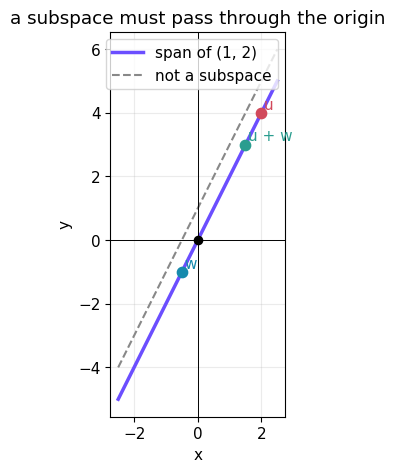

In [12]:
t = np.linspace(-2.5, 2.5, 200)

fig, ax = plt.subplots()
ax.plot(t, 2 * t, color="#6b4eff", linewidth=2.5, label="span of (1, 2)")
ax.plot(t, 2 * t + 1, color="#888888", linestyle="--", label="not a subspace")

for label, point, color in [
    ("u", u, "#d1495b"),
    ("w", w, "#168aad"),
    ("u + w", vector_sum, "#2a9d8f"),
]:
    ax.scatter(*point, s=55, color=color, zorder=3)
    ax.annotate(label, point + np.array([0.08, 0.12]), color=color)

ax.scatter(0, 0, s=35, color="black", zorder=3)
ax.axhline(0, color="black", linewidth=0.7)
ax.axvline(0, color="black", linewidth=0.7)
ax.set(xlabel="x", ylabel="y", title="a subspace must pass through the origin")
ax.set_aspect("equal", adjustable="box")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

For the chosen vectors, we get $u+w=1.5v$, which stays in $V$ because it is another multiple of $v$. We can also write the zero vector as $0v$, so it belongs to $V$ as well. I included the dashed line for comparison. It misses the origin, so it is not a subspace of $\mathbb{R}^2$.

## 1.2.2 orthogonality

Two vectors are orthogonal when their dot product is zero. For nonzero vectors, this means the angle between them is 90 degrees. The first calculation checks this directly with a pair of vectors.

Next, for a nonzero $u$, we use a projection to split $x$ into a part parallel to $u$ and a residual perpendicular to $u$:

$$
\operatorname{proj}_u(x)=\frac{x^T u}{u^T u}u,
\qquad
r=x-\operatorname{proj}_u(x).
$$

In [13]:
u_orth = np.array([3.0, 4.0])
v_orth = np.array([-4.0, 3.0])
x = np.array([5.0, 1.0])

dot_uv = np.dot(u_orth, v_orth)
projection = (np.dot(x, u_orth) / np.dot(u_orth, u_orth)) * u_orth
residual = x - projection

print("u dot v =", dot_uv)
print("projection of x onto u =", projection)
print("residual =", residual)
print("u dot residual =", np.dot(u_orth, residual))

assert np.isclose(dot_uv, 0.0)
assert np.isclose(np.dot(u_orth, residual), 0.0)
assert np.allclose(x, projection + residual)

u dot v = 0.0
projection of x onto u = [2.28 3.04]
residual = [ 2.72 -2.04]
u dot residual = 0.0


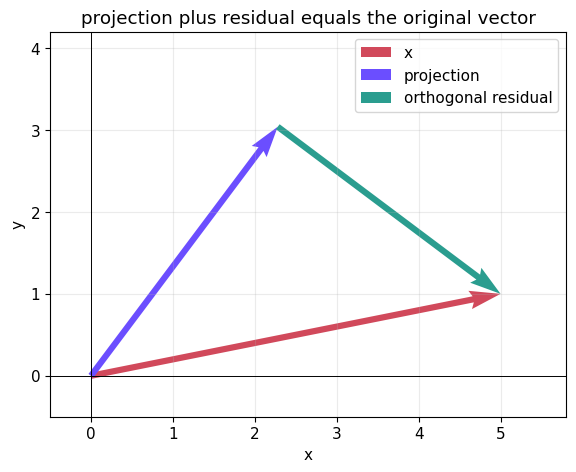

In [14]:
fig, ax = plt.subplots()

ax.quiver(0, 0, *x, angles="xy", scale_units="xy", scale=1,
          color="#d1495b", width=0.012, label="x")
ax.quiver(0, 0, *projection, angles="xy", scale_units="xy", scale=1,
          color="#6b4eff", width=0.012, label="projection")
ax.quiver(*projection, *residual, angles="xy", scale_units="xy", scale=1,
          color="#2a9d8f", width=0.012, label="orthogonal residual")

ax.axhline(0, color="black", linewidth=0.7)
ax.axvline(0, color="black", linewidth=0.7)
ax.set_xlim(-0.5, 5.8)
ax.set_ylim(-0.5, 4.2)
ax.set_aspect("equal", adjustable="box")
ax.set(xlabel="x", ylabel="y", title="projection plus residual equals the original vector")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

The calculation gives $u^T v=0$, so $u$ and $v$ are orthogonal. We also get $u^T r=0$, which shows that the residual is perpendicular to $u$. Since $x=\operatorname{proj}_u(x)+r$, the vector $x$ is split into parallel and perpendicular parts.

## 1.2.3 Gram-Schmidt process

Gram-Schmidt turns linearly independent vectors into an orthonormal set without changing their span. In this implementation, we remove each new vector's projections onto the earlier orthonormal vectors, then normalize what remains.

The resulting vectors form the columns of $Q$. The two checks are $Q^TQ=I$ and $QR=A$.

In [15]:
def gram_schmidt(matrix, tolerance=1e-10):
    q_columns = []

    for column in matrix.T:
        remaining = column.astype(float).copy()

        # remove the parts pointing along earlier q vectors
        for q in q_columns:
            remaining = remaining - np.dot(remaining, q) * q

        length = np.linalg.norm(remaining)
        if length < tolerance:
            raise ValueError("The input vectors must be linearly independent.")

        q_columns.append(remaining / length)

    return np.column_stack(q_columns)


# the input vectors are the columns of A
A_gs = np.array([
    [1.0, 1.0, 0.0],
    [1.0, 0.0, 1.0],
    [0.0, 1.0, 1.0],
])

Q = gram_schmidt(A_gs)
R = Q.T @ A_gs
gram_matrix = Q.T @ Q
reconstruction_error = np.max(np.abs(A_gs - Q @ R))

print("A =\n", A_gs)
print("\nQ =\n", Q)
print("\nQ.T @ Q =\n", gram_matrix)
print("\nmaximum reconstruction error =", reconstruction_error)

assert np.allclose(gram_matrix, np.eye(3))
assert np.allclose(Q @ R, A_gs)

A =
 [[1. 1. 0.]
 [1. 0. 1.]
 [0. 1. 1.]]

Q =
 [[ 0.707  0.408 -0.577]
 [ 0.707 -0.408  0.577]
 [ 0.     0.816  0.577]]

Q.T @ Q =
 [[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]

maximum reconstruction error = 4.440892098500626e-16


The computed matrix $Q^TQ$ is numerically equal to $I$. The off-diagonal entries are zero up to rounding because different columns are orthogonal, and the diagonal entries are one because every column has unit length. We also reconstruct $A$ with $QR$. The maximum error, about $4.44\times10^{-16}$, comes from floating-point rounding.

## 1.2.4 eigenvalues and eigenvectors

A nonzero vector $v$ is an eigenvector of $A$ when

$$
Av=\lambda v.
$$

Multiplying by $A$ keeps $v$ on the same line. The eigenvalue $\lambda$ gives the scale factor and tells us whether the direction is reversed.

I chose a symmetric matrix so `np.linalg.eigh` returns real eigenvalues and orthonormal eigenvectors. We then check each pair with $Av-\lambda v$ and calculate $Ax$ a second way in the eigenvector basis.

In [16]:
A_eig = np.array([
    [3.0, 1.0],
    [1.0, 3.0],
])

eigenvalues, eigenvectors = np.linalg.eigh(A_eig)

print("eigenvalues =", eigenvalues)
print("eigenvectors are the columns of\n", eigenvectors)

for index, eigenvalue in enumerate(eigenvalues):
    eigenvector = eigenvectors[:, index]
    residual_size = np.linalg.norm(A_eig @ eigenvector - eigenvalue * eigenvector)
    print(f"check {index + 1}: ||Av - lambda v|| = {residual_size:.2e}")
    assert residual_size < 1e-12

# any vector can be handled using its coordinates in the eigenvector basis
x_eig = np.array([2.0, 1.0])
coordinates = eigenvectors.T @ x_eig
direct_result = A_eig @ x_eig
eigenbasis_result = eigenvectors @ (eigenvalues * coordinates)

print("\nx =", x_eig)
print("coordinates in the eigenvector basis =", coordinates)
print("A @ x =", direct_result)
print("result from eigenvalue scaling =", eigenbasis_result)

assert np.allclose(direct_result, eigenbasis_result)

eigenvalues = [2. 4.]
eigenvectors are the columns of
 [[-0.707  0.707]
 [ 0.707  0.707]]
check 1: ||Av - lambda v|| = 0.00e+00
check 2: ||Av - lambda v|| = 0.00e+00

x = [2. 1.]
coordinates in the eigenvector basis = [-0.707  2.121]
A @ x = [7. 5.]
result from eigenvalue scaling = [7. 5.]


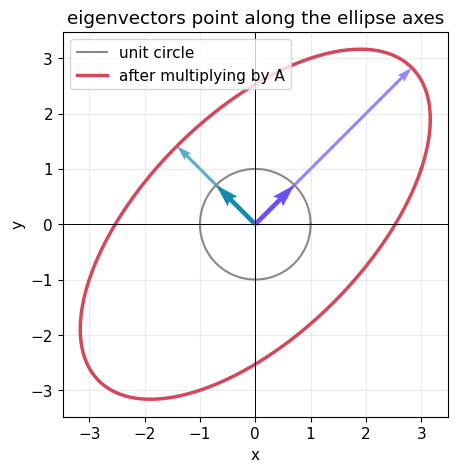

In [17]:
theta = np.linspace(0, 2 * np.pi, 400)
unit_circle = np.vstack((np.cos(theta), np.sin(theta)))
transformed_circle = A_eig @ unit_circle

fig, ax = plt.subplots()
ax.plot(unit_circle[0], unit_circle[1], color="#888888", label="unit circle")
ax.plot(transformed_circle[0], transformed_circle[1], color="#d1495b",
        linewidth=2.5, label="after multiplying by A")

colors = ["#168aad", "#6b4eff"]
for eigenvalue, eigenvector, color in zip(eigenvalues, eigenvectors.T, colors):
    ax.quiver(0, 0, *eigenvector, angles="xy", scale_units="xy", scale=1,
              color=color, width=0.012)
    ax.quiver(0, 0, *(eigenvalue * eigenvector), angles="xy",
              scale_units="xy", scale=1, color=color, width=0.008, alpha=0.7)

ax.axhline(0, color="black", linewidth=0.7)
ax.axvline(0, color="black", linewidth=0.7)
ax.set_aspect("equal", adjustable="box")
ax.set(xlabel="x", ylabel="y", title="eigenvectors point along the ellipse axes")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

For this symmetric matrix, the eigenvalues are 2 and 4. Applying $A$ keeps each eigenvector on its original line and scales it by the corresponding eigenvalue. In the plot, we can see those directions become the principal axes of the transformed circle.

## final checks

The next code cell collects the main numerical checks from the notebook. Each one should print `True`.

In [18]:
checks = {
    "linear space closure": in_span_of_v(vector_sum, v),
    "orthogonal vectors": np.isclose(dot_uv, 0.0),
    "projection residual is orthogonal": np.isclose(np.dot(u_orth, residual), 0.0),
    "Gram-Schmidt columns are orthonormal": np.allclose(Q.T @ Q, np.eye(3)),
    "eigenvector equations hold": np.allclose(
        A_eig @ eigenvectors, eigenvectors @ np.diag(eigenvalues)
    ),
}

for name, passed in checks.items():
    print(f"{name}: {passed}")

assert all(checks.values())

linear space closure: True
orthogonal vectors: True
projection residual is orthogonal: True
Gram-Schmidt columns are orthonormal: True
eigenvector equations hold: True


## conclusion

From these examples, we can see that a span stays closed under linear combinations, orthogonal vectors have zero dot product, and projection splits a vector into parallel and perpendicular parts. I used Gram-Schmidt to turn independent vectors into an orthonormal basis for their span and checked that $QR$ reconstructs the original matrix. In the final example, the eigenvectors identified lines preserved by the matrix, while the eigenvalues gave the scale factors along those lines.

## notes and references

- Ren, J., and Wang, H. (2023). *Mathematical Methods in Data Science*. Elsevier.
- NumPy was used for the vector and matrix calculations. Matplotlib was used for the figures.
- AI use note: I had help from Codex in refining the code (not completely writing it), refining the latex of the report, and pushing it to GitHub. Other than that, the intial psuedocode/boilerplates, logic, and the report is still drafted by me. I ran every cell and reviewed the math and explanations before submitting.